### Importing important libraries.

In [136]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Importing OS and defining path for fetching data this folder.

In [137]:
import os
# .. by using this we can define the ouside way of folders for fetching data from any folder on the main folder if avilable.(relative path)
print("Files inside data folder:", os.listdir('../DataSets'))

Files inside data folder: ['purchase_behaviour.csv', 'transaction_data.xlsx']


### Data Fetching --

In [138]:
tran_df = pd.read_excel('../DataSets/transaction_data.xlsx')
transaction = pd.DataFrame(tran_df)
print(transaction.head())

    DATE  STORE_NBR  LYLTY_CARD_NBR  TXN_ID  PROD_NBR  \
0  43390          1            1000       1         5   
1  43599          1            1307     348        66   
2  43605          1            1343     383        61   
3  43329          2            2373     974        69   
4  43330          2            2426    1038       108   

                                  PROD_NAME  PROD_QTY  TOT_SALES  
0    Natural Chip        Compny SeaSalt175g         2        6.0  
1                  CCs Nacho Cheese    175g         3        6.3  
2    Smiths Crinkle Cut  Chips Chicken 170g         2        2.9  
3    Smiths Chip Thinly  S/Cream&Onion 175g         5       15.0  
4  Kettle Tortilla ChpsHny&Jlpno Chili 150g         3       13.8  


In [139]:
behaviour_df = pd.read_csv('../DataSets/purchase_behaviour.csv')
transaction = pd.DataFrame(behaviour_df)
print(transaction.head())

   LYLTY_CARD_NBR               LIFESTAGE PREMIUM_CUSTOMER
0            1000   YOUNG SINGLES/COUPLES          Premium
1            1002   YOUNG SINGLES/COUPLES       Mainstream
2            1003          YOUNG FAMILIES           Budget
3            1004   OLDER SINGLES/COUPLES       Mainstream
4            1005  MIDAGE SINGLES/COUPLES       Mainstream


### Checking for null values --

In [140]:
tran_df.isnull().sum()

DATE              0
STORE_NBR         0
LYLTY_CARD_NBR    0
TXN_ID            0
PROD_NBR          0
PROD_NAME         0
PROD_QTY          0
TOT_SALES         0
dtype: int64

In [141]:
behaviour_df.isnull().sum()

LYLTY_CARD_NBR      0
LIFESTAGE           0
PREMIUM_CUSTOMER    0
dtype: int64

### Checking Outliers --

In [142]:
display(tran_df.describe())

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_QTY,TOT_SALES
count,264836.000000,264836.00000,2.648360e+05,2.648360e+05,264836.000000,264836.000000,264836.000000
mean,43464.036260,135.08011,1.355495e+05,1.351583e+05,56.583157,1.907309,7.304200
std,105.389282,76.78418,8.057998e+04,7.813303e+04,32.826638,0.643654,3.083226
min,43282.000000,1.00000,1.000000e+03,1.000000e+00,1.000000,1.000000,1.500000
25%,43373.000000,70.00000,7.002100e+04,6.760150e+04,28.000000,2.000000,5.400000
50%,43464.000000,130.00000,1.303575e+05,1.351375e+05,56.000000,2.000000,7.400000
75%,43555.000000,203.00000,2.030942e+05,2.027012e+05,85.000000,2.000000,9.200000
max,43646.000000,272.00000,2.373711e+06,2.415841e+06,114.000000,200.000000,650.000000


#### Indentifying customer having max purchase as outlier value of qty-

In [143]:
outlier_cust = tran_df[tran_df['PROD_QTY'] == 200]
outlier_cust

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
69762,43331,226,226000,226201,4,Dorito Corn Chp Supreme 380g,200,650.0
69763,43605,226,226000,226210,4,Dorito Corn Chp Supreme 380g,200,650.0


#### Searching for outlier customer history to confirm that its a regular customer or not.

In [144]:
cust_history = tran_df[tran_df['LYLTY_CARD_NBR'] == 226000]
cust_history

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
69762,43331,226,226000,226201,4,Dorito Corn Chp Supreme 380g,200,650.0
69763,43605,226,226000,226210,4,Dorito Corn Chp Supreme 380g,200,650.0


#### Removing the outlier customer details.

In [145]:
tran_df = tran_df.drop(tran_df[tran_df['LYLTY_CARD_NBR'] == 226000].index) # above output will be empty because after identifying it we removed it.

In [146]:
behaviour_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 72637 entries, 0 to 72636
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   LYLTY_CARD_NBR    72637 non-null  int64
 1   LIFESTAGE         72637 non-null  str  
 2   PREMIUM_CUSTOMER  72637 non-null  str  
dtypes: int64(1), str(2)
memory usage: 1.7 MB


### Identifying the outlier customer.

In [147]:
cst_history = behaviour_df[behaviour_df['LYLTY_CARD_NBR'] == 226000]
cst_history

,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER
59694,226000,OLDER FAMILIES,Premium


#### Removing that outlier customer from behaviour table.

In [148]:
behaviour_df = behaviour_df.drop(behaviour_df[behaviour_df['LYLTY_CARD_NBR'] == 226000].index) # above output will be empty because after identifying it we removed it.

### Fixing date format in transaction table.

In [149]:
import dateutil.parser as parser

In [150]:
##def clean_date(date):
##    try:
##      return parser.parse(str(date))
##    except:
##       return pd.NaT 
## This will not work in this case because of the date format is in number of days since 1899-12-30. So we will use another method to convert it.

In [151]:
tran_df.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,43390,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,43599,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,43605,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,43329,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,43330,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8


In [152]:
tran_df['DATE'] = pd.to_datetime(tran_df['DATE'],unit='D', origin='1899-12-30',errors='coerce') # text coverted into date time format by using this method.
tran_df.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8


### Feature extraction -- In this we will extract packet size from its description(product_name).

In [153]:
tran_df['PACK_SIZE'] = tran_df['PROD_NAME'].str.extract(r'(\d+)')


In [154]:
tran_df.head(10)

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0,175
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3,175
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9,170
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0,175
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8,150
5,2019-05-19,4,4074,2982,57,Old El Paso Salsa Dip Tomato Mild 300g,1,5.1,300
6,2019-05-16,4,4149,3333,16,Smiths Crinkle Chips Salt & Vinegar 330g,1,5.7,330
7,2019-05-16,4,4196,3539,24,Grain Waves Sweet Chilli 210g,1,3.6,210
8,2018-08-20,5,5026,4525,42,Doritos Corn Chip Mexican Jalapeno 150g,1,3.9,150
9,2018-08-18,7,7150,6900,52,Grain Waves Sour Cream&Chives 210G,2,7.2,210


### Extracting brand name.

In [158]:
tran_df['BRAND_NAME'] = tran_df['PROD_NAME'].str.extract(r'^([a-zA-Z]+)')

In [162]:
tran_df.head(10)

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND_NAME
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0,175,Natural
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3,175,CCs
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9,170,Smiths
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0,175,Smiths
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8,150,Kettle
5,2019-05-19,4,4074,2982,57,Old El Paso Salsa Dip Tomato Mild 300g,1,5.1,300,Old
6,2019-05-16,4,4149,3333,16,Smiths Crinkle Chips Salt & Vinegar 330g,1,5.7,330,Smiths
7,2019-05-16,4,4196,3539,24,Grain Waves Sweet Chilli 210g,1,3.6,210,Grain
8,2018-08-20,5,5026,4525,42,Doritos Corn Chip Mexican Jalapeno 150g,1,3.9,150,Doritos
9,2018-08-18,7,7150,6900,52,Grain Waves Sour Cream&Chives 210G,2,7.2,210,Grain


### Cheking for brand name.

In [209]:
bran = tran_df[tran_df['BRAND_NAME'] == 'Natural Chips Co']
bran

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND_NAME
17,2018-08-14,22,22411,18646,98,NCC Sour Cream & Garden Chives 175g,1,3.0,175,Natural Chips Co
21,2018-08-16,33,33081,29949,98,NCC Sour Cream & Garden Chives 175g,1,3.0,175,Natural Chips Co
437,2018-08-28,13,13176,12211,98,NCC Sour Cream & Garden Chives 175g,2,6.0,175,Natural Chips Co
535,2019-01-16,22,22131,18288,98,NCC Sour Cream & Garden Chives 175g,2,6.0,175,Natural Chips Co
828,2019-02-18,41,41087,38000,98,NCC Sour Cream & Garden Chives 175g,2,6.0,175,Natural Chips Co
...,...,...,...,...,...,...,...,...,...,...
264307,2018-07-03,248,248244,250500,98,NCC Sour Cream & Garden Chives 175g,2,6.0,175,Natural Chips Co
264360,2019-03-05,249,249354,251273,98,NCC Sour Cream & Garden Chives 175g,1,3.0,175,Natural Chips Co
264636,2019-06-11,264,264268,263027,98,NCC Sour Cream & Garden Chives 175g,1,3.0,175,Natural Chips Co
264721,2018-08-21,266,266329,264152,98,NCC Sour Cream & Garden Chives 175g,1,3.0,175,Natural Chips Co


### Check for unique brand name so that same names can be replace with one sigle name so that no miss calculation will happen.

In [163]:
print(tran_df['BRAND_NAME'].unique()) # checking for unique name for identifying the names of brand.

<StringArray>
[   'Natural',        'CCs',     'Smiths',     'Kettle',        'Old',
      'Grain',    'Doritos',   'Twisties',         'WW',      'Thins',
     'Burger',        'NCC',   'Cheezels',     'Infzns',        'Red',
   'Pringles',     'Dorito',  'Infuzions',      'Smith',    'GrnWves',
   'Tyrrells',       'Cobs', 'Woolworths',     'French',        'RRD',
   'Tostitos',    'Cheetos',      'Snbts',   'Sunbites']
Length: 29, dtype: str


#### Renaming duplicate brand name to its original.

In [207]:
brand_name = {
    'Dorito': 'Doritos',
    'Red': 'Red Rock Deli',
    'Smith': 'Smiths',
    'Snbts': 'Sunbites',
    'WW': 'Woolworths',
    'Infzns': 'Infuzions',
    'GrnWves': 'Grain Waves',
    'Natural Chip Co' : 'Natural Chips Co' 
    }  # renaming the short name to their full name for not to idenfy then seperately and for correct calculation.

In [208]:
tran_df['BRAND_NAME'] = tran_df['BRAND_NAME'].replace(brand_name)
tran_df.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND_NAME
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0,175,Natural
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3,175,CCs
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9,170,Smiths
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0,175,Smiths
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8,150,Kettle


In [195]:
print(tran_df['BRAND_NAME'].unique()) # after replacing the short name with full name we can see that there is no short name in the unique name list.

<StringArray>
[      'Natural',           'CCs',        'Smiths',        'Kettle',
           'Old',         'Grain',       'Doritos',      'Twisties',
    'Woolworths',         'Thins',        'Burger',           'NCC',
      'Cheezels',     'Infuzions', 'Red Rock Deli',      'Pringles',
   'Grain Waves',      'Tyrrells',          'Cobs',        'French',
      'Tostitos',       'Cheetos',      'Sunbites']
Length: 23, dtype: str


In [210]:
behaviour_df.head(10)

,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,YOUNG SINGLES/COUPLES,Premium
1,1002,YOUNG SINGLES/COUPLES,Mainstream
2,1003,YOUNG FAMILIES,Budget
3,1004,OLDER SINGLES/COUPLES,Mainstream
4,1005,MIDAGE SINGLES/COUPLES,Mainstream
5,1007,YOUNG SINGLES/COUPLES,Budget
6,1009,NEW FAMILIES,Premium
7,1010,YOUNG SINGLES/COUPLES,Mainstream
8,1011,OLDER SINGLES/COUPLES,Mainstream
9,1012,OLDER FAMILIES,Mainstream


### Joining both Tables.

In [211]:
full_df = pd.merge(tran_df, behaviour_df, on= 'LYLTY_CARD_NBR', how = 'left') # merging the two data frame on the basis of loyalty card number for getting the full data in one data frame.

#### Checking for null values after joining the both table.

In [214]:
full_df.isnull().sum()

DATE                0
STORE_NBR           0
LYLTY_CARD_NBR      0
TXN_ID              0
PROD_NBR            0
PROD_NAME           0
PROD_QTY            0
TOT_SALES           0
PACK_SIZE           0
BRAND_NAME          0
LIFESTAGE           0
PREMIUM_CUSTOMER    0
dtype: int64

In [215]:
full_df.head(10)

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND_NAME,LIFESTAGE,PREMIUM_CUSTOMER
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0,175,Natural,YOUNG SINGLES/COUPLES,Premium
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3,175,CCs,MIDAGE SINGLES/COUPLES,Budget
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9,170,Smiths,MIDAGE SINGLES/COUPLES,Budget
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0,175,Smiths,MIDAGE SINGLES/COUPLES,Budget
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8,150,Kettle,MIDAGE SINGLES/COUPLES,Budget
5,2019-05-19,4,4074,2982,57,Old El Paso Salsa Dip Tomato Mild 300g,1,5.1,300,Old,MIDAGE SINGLES/COUPLES,Budget
6,2019-05-16,4,4149,3333,16,Smiths Crinkle Chips Salt & Vinegar 330g,1,5.7,330,Smiths,MIDAGE SINGLES/COUPLES,Budget
7,2019-05-16,4,4196,3539,24,Grain Waves Sweet Chilli 210g,1,3.6,210,Grain,MIDAGE SINGLES/COUPLES,Budget
8,2018-08-20,5,5026,4525,42,Doritos Corn Chip Mexican Jalapeno 150g,1,3.9,150,Doritos,MIDAGE SINGLES/COUPLES,Budget
9,2018-08-18,7,7150,6900,52,Grain Waves Sour Cream&Chives 210G,2,7.2,210,Grain,MIDAGE SINGLES/COUPLES,Budget


### Group by data for findind the sales according to customer.

In [225]:
identification = full_df.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER'])['TOT_SALES'].sum().sort_values(ascending=False) # grouping the data on the basis of lifestage and premium customer status for getting the total sales for each group and then sorting it in descending order.
master_df = pd.DataFrame(identification)
master_df

TOT_SALES
LIFESTAGE              PREMIUM_CUSTOMER           
OLDER FAMILIES         Budget            168363.25
YOUNG SINGLES/COUPLES  Mainstream        157621.60
RETIREES               Mainstream        155677.05
YOUNG FAMILIES         Budget            139345.85
OLDER SINGLES/COUPLES  Budget            136769.80
                       Mainstream        133393.80
                       Premium           132263.15
RETIREES               Budget            113147.80
OLDER FAMILIES         Mainstream        103445.55
RETIREES               Premium            97646.05
YOUNG FAMILIES         Mainstream         92788.75
MIDAGE SINGLES/COUPLES Mainstream         90803.85
YOUNG FAMILIES         Premium            84025.50
OLDER FAMILIES         Premium            80658.40
YOUNG SINGLES/COUPLES  Budget             61141.60
MIDAGE SINGLES/COUPLES Premium            58432.65
YOUNG SINGLES/COUPLES  Premium            41642.10
MIDAGE SINGLES/COUPLES Budget             35514.80
NEW FAMILIES           Budget             21928.45
                       Mainstream         17013.90
                       Premium            11491.10

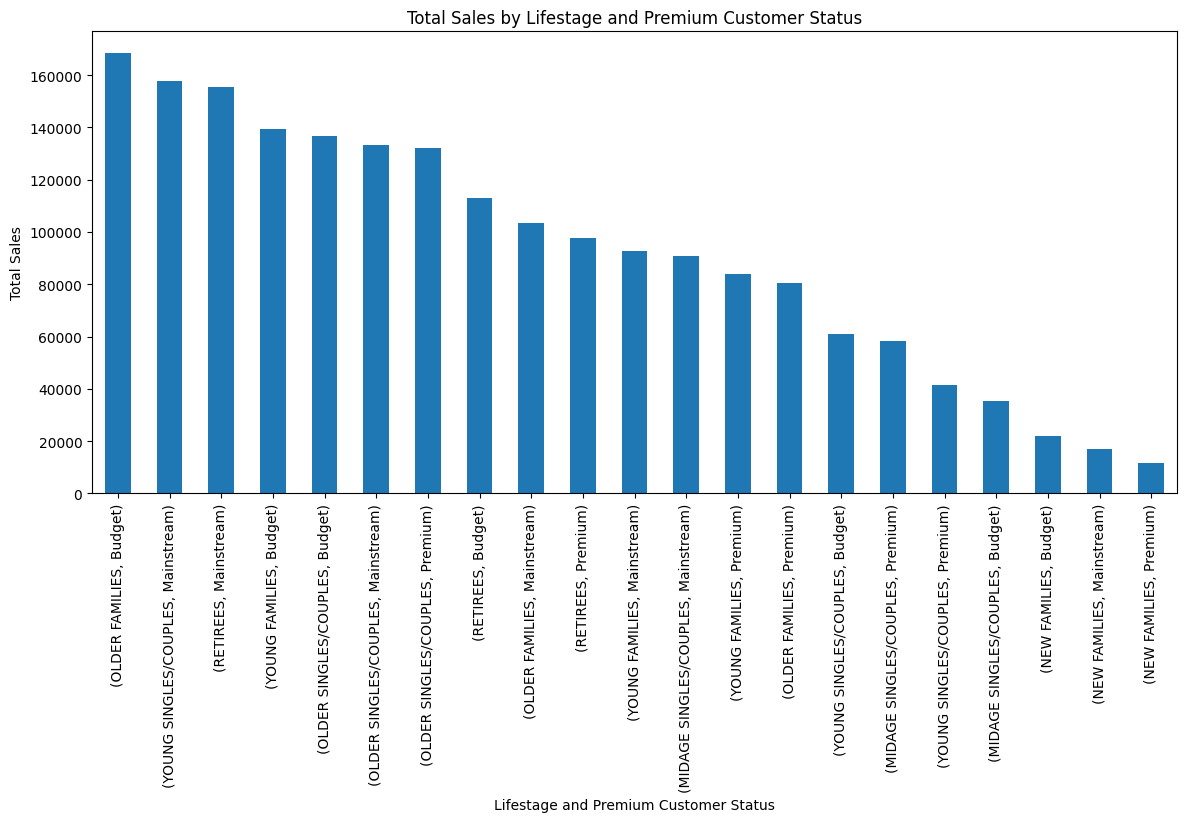

In [224]:
identification.plot(kind='bar', figsize=(14,6))
plt.title('Total Sales by Lifestage and Premium Customer Status')
plt.xlabel('Lifestage and Premium Customer Status')
plt.ylabel('Total Sales')
plt.xticks(rotation=90)
plt.show()